# Загрузка библиотек

In [68]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import ResNet50V2
import matplotlib.pyplot as plt
import numpy as np
import os

# Загрузка данных

In [32]:
train_path = "seg_train" # Путь до файлов (разбито на подпапки с названиями классов)
BS = 32 # Размер батча
class_names = [x for x in os.listdir(train_path)]

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)  

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


train_data = train_datagen.flow_from_directory(train_path, 
                                               target_size=(224, 224), 
                                               color_mode='rgb',
                                               batch_size=BS, 
                                               class_mode='categorical',
                                               shuffle=True,
                                               subset = 'training') 

test_data = test_datagen.flow_from_directory(train_path, 
                                           target_size=(224, 224), 
                                           color_mode='rgb',
                                           batch_size=BS, 
                                           class_mode='categorical',
                                           shuffle=False,
                                           subset = 'validation')

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [19]:
train_data.class_indices.keys()

dict_keys(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])

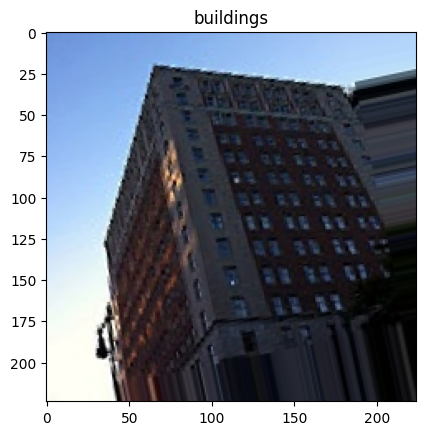

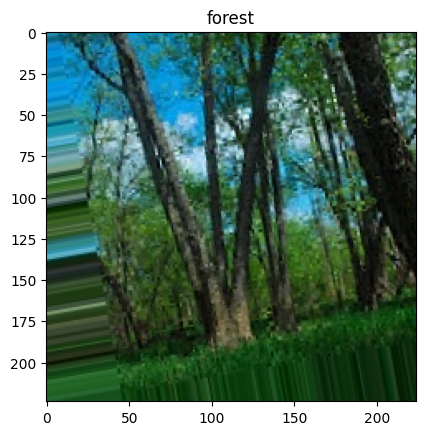

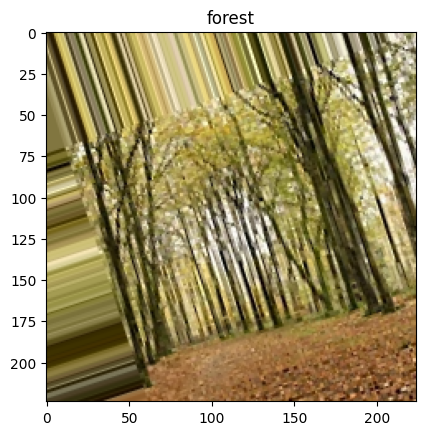

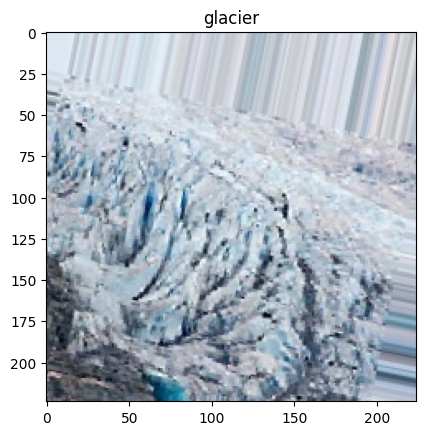

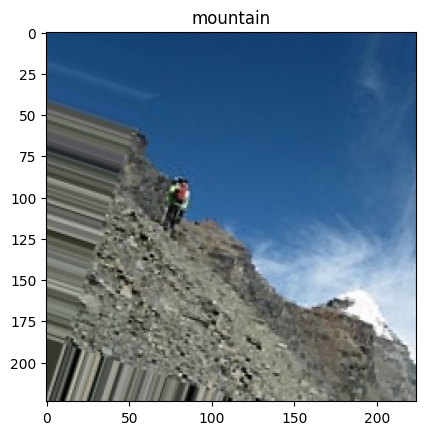

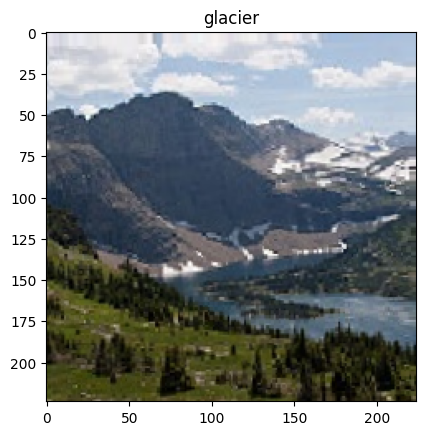

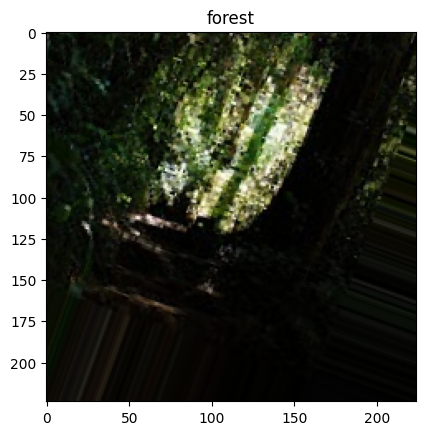

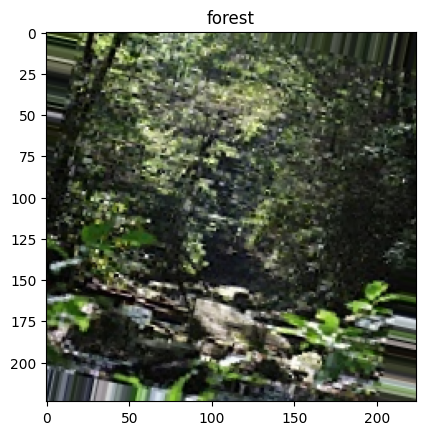

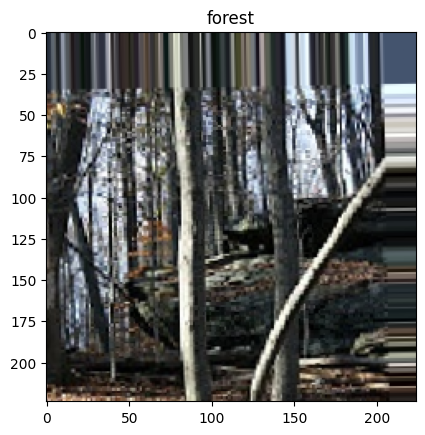

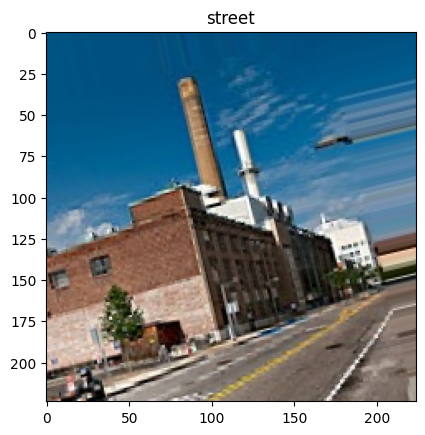

In [34]:
x_batch, y_batch = train_data[0]

for i in range (0,10):
    image = x_batch[i]
    label_index = np.argmax(y_batch[i])
    label = class_names[label_index]
    plt.imshow(image)
    plt.title(label)
    plt.show()

# Построение модели с нуля

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(224,224,3)),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 224, 224, 64)      1792      
                                                                 
 conv2d_23 (Conv2D)          (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 112, 112, 64)     0         
 g2D)                                                            
                                                                 
 conv2d_24 (Conv2D)          (None, 112, 112, 128)     73856     
                                                                 
 conv2d_25 (Conv2D)          (None, 112, 112, 128)     147584    
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 56, 56, 128)      0         
 g2D)                                                 

In [ ]:
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
    Precision(name='precision'),
    Recall(name='recall'),]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/50
351/351 [==============================] - 152s 374ms/step - loss: 1.3089 - accuracy: 0.4565 - precision: 0.6790 - recall: 0.2508 - val_loss: 0.8927 - val_accuracy: 0.6384 - val_precision: 0.7912 - val_recall: 0.4893
Epoch 2/50
121/351 [=========>....................] - ETA: 48s - loss: 1.0054 - accuracy: 0.5897 - precision: 0.7341 - recall: 0.4181

KeyboardInterrupt: 

In [ ]:
model.save('Model_intel_ACC87.h5')
print(model.evaluate(train_data))
print(model.evaluate(test_data))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

351/351 [==============================] - 53s 149ms/step - loss: 0.9497 - accuracy: 0.6060 - precision: 0.7599 - recall: 0.4028
[0.9496973752975464, 0.6059661507606506, 0.7599126100540161, 0.40276047587394714]
88/88 [==============================] - 5s 54ms/step - loss: 0.9160 - accuracy: 0.6323 - precision: 0.7808 - recall: 0.4369
[0.9159736633300781, 0.6323109865188599, 0.7807520627975464, 0.4368758797645569]


NameError: name 'history' is not defined

## Дообучение модели

In [67]:
# Load base model
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers
base_model.trainable = False

# Add new layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Better than MaxPooling for transfer learning
x = Dense(1024, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

TypeError: Sequential.call() got an unexpected keyword argument 'outputs'

In [69]:
model = Model(base_model.input, predictions)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_5[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [70]:
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
    Precision(name='precision'),
    Recall(name='recall'),]
)

In [71]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/50
 97/351 [=======>......................] - ETA: 37s - loss: 0.5021 - accuracy: 0.8186 - precision: 0.8461 - recall: 0.7986

KeyboardInterrupt: 

In [72]:
model.save('Model_intel_ACC87.h5')
print(model.evaluate(train_data))
print(model.evaluate(test_data))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

  7/351 [..............................] - ETA: 45s - loss: 0.3939 - accuracy: 0.8929 - precision: 0.8991 - recall: 0.8750

KeyboardInterrupt: 

# Предсказание

In [ ]:
image_example, _ = train_data[0]

(224, 224, 3)

In [77]:
image_example, _ = train_data[0]
model.predict(image_example)

1/1 [==============================] - 1s 732ms/step


array([[7.28826784e-03, 2.04490311e-06, 1.03484826e-05, 1.99349824e-06,
        4.86271347e-06, 9.92692471e-01],
       [5.06301178e-04, 1.06892618e-03, 5.93825579e-01, 4.02766973e-01,
        1.39921729e-03, 4.33021865e-04],
       [3.85008061e-05, 9.99390483e-01, 1.49899133e-04, 1.64450743e-04,
        4.59065668e-05, 2.10659302e-04],
       [1.67377032e-02, 1.34575404e-02, 2.32097022e-02, 9.09608126e-01,
        3.04888524e-02, 6.49814354e-03],
       [2.75214901e-04, 4.42598341e-03, 5.84846139e-01, 4.09868240e-01,
        7.08424122e-05, 5.13535691e-04],
       [9.81760323e-01, 8.14030427e-05, 1.42659177e-04, 7.23695484e-05,
        1.76063331e-04, 1.77671276e-02],
       [1.58019349e-01, 7.70865474e-04, 5.87928575e-03, 2.55203154e-02,
        9.07009188e-03, 8.00740123e-01],
       [2.78172938e-05, 2.19000467e-05, 4.67844121e-02, 9.51168686e-03,
        9.43402231e-01, 2.51870137e-04],
       [4.82758187e-04, 5.78217255e-03, 4.31172788e-01, 5.35096169e-01,
        2.60967724e-02, 